In [ ]:
!pip install google-api-python-client transformers torch pandas \
             matplotlib seaborn tqdm sentencepiece protobuf

In [ ]:
YOUTUBE_API_KEY = "MASUKKAN_API_KEY_ANDA_DI_SINI"

VIDEO_URLS = [
    "https://www.youtube.com/watch?v=ndzTvwrgtQA",
    "https://www.youtube.com/watch?v=GHQo30fnKk8",
    "https://www.youtube.com/watch?v=JSbz7u-fhfw",
    "https://www.youtube.com/watch?v=MmXNLPs155U",
    "https://www.youtube.com/watch?v=E8q-DQGgukw",
    "https://www.youtube.com/watch?v=76qp5w9uDeE",
    "https://www.youtube.com/watch?v=LI3iOP-9VCc",
    "https://www.youtube.com/watch?v=kL5paxuuYdA",
    "https://www.youtube.com/watch?v=w8IlPHqLLfU",
    "https://www.youtube.com/watch?v=x-7fjnb-aGo",
]


VIDEO_GROUP_MAP = {}

SENTIMENT_MODEL = "mdhugol/indonesia-bert-sentiment-classification"
MAX_COMMENTS_PER_VIDEO = None

MIN_WORD_COUNT = 5

OUTPUT_CSV         = "hasil_sentimen_semua_komentar.csv"
VALIDATION_CSV     = "sampel_validasi_manual.csv"
VISUALIZATION_FILE = "visualisasi_sentimen.png"


In [ ]:
import re
import sys
import random
import logging
from urllib.parse import urlparse, parse_qs
from typing import Optional

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

from googleapiclient.discovery import build
from googleapiclient.errors import HttpError

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

# Setup
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger(__name__)



In [ ]:
def extract_video_id(url: str) -> str:
    """
    Mengekstrak video ID dari berbagai format URL YouTube.

    Mendukung format:
    - https://www.youtube.com/watch?v=VIDEO_ID
    - https://youtu.be/VIDEO_ID
    - https://www.youtube.com/shorts/VIDEO_ID (baru)
    - VIDEO_ID langsung (11 karakter)

    Args:
        url: URL YouTube atau video ID mentah.

    Returns:
        String video ID (11 karakter).

    Raises:
        ValueError: Jika format URL tidak dikenali.
    """
    url = url.strip()

    # Jika sudah berupa video ID (11 karakter alfanumerik + - _)
    if re.match(r'^[A-Za-z0-9_-]{11}$', url):
        return url

    # Parse URL standar
    parsed = urlparse(url)
    if parsed.hostname in ("www.youtube.com", "youtube.com"):
        qs = parse_qs(parsed.query)
        if "v" in qs:
            return qs["v"][0]

        if parsed.path.startswith("/shorts/") and len(parsed.path) == 18: # /shorts/ + 11 chars
            return parsed.path[len("/shorts/"):]

    if parsed.hostname == "youtu.be":
        return parsed.path.lstrip("/")

    raise ValueError(f"Format URL YouTube tidak dikenali: {url}")


def build_youtube_client(api_key: str):
    """
    Membangun client YouTube Data API v3.

    Args:
        api_key: API key Google yang valid.

    Returns:
        Object Resource YouTube API.
    """
    return build("youtube", "v3", developerKey=api_key)


def fetch_comments_for_video(
    youtube_client,
    video_id: str,
    max_results: Optional[int] = None,
) -> list[dict]:
    """
    Mengambil semua komentar top-level dari satu video YouTube.

    Melakukan paginasi otomatis menggunakan nextPageToken hingga
    semua komentar terambil atau batas max_results tercapai.

    Args:
        youtube_client : Client YouTube API.
        video_id       : ID video YouTube.
        max_results    : Batas maksimum komentar. None = ambil semua.

    Returns:
        List of dict, masing-masing berisi:
        {video_id, comment_id, author, teks_asli, jumlah_like, published_at}
    """
    comments = []
    next_page_token = None

    logger.info(f"  Mengambil komentar untuk video: {video_id}")

    while True:
        try:
            request = youtube_client.commentThreads().list(
                part="snippet",
                videoId=video_id,
                maxResults=100,           # Maksimum per halaman (batas API)
                pageToken=next_page_token,
                textFormat="plainText",   # Teks biasa, bukan HTML
                order="relevance",        # Urutkan berdasarkan relevansi
            )
            response = request.execute()

        except HttpError as e:
            if e.resp.status == 403:
                logger.warning(f"  Komentar dinonaktifkan untuk video {video_id}. Dilewati.")
            else:
                logger.error(f"  HTTP Error {e.resp.status} untuk video {video_id}: {e}")
            break

        for item in response.get("items", []):
            snippet = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "video_id"   : video_id,
                "comment_id" : item["snippet"]["topLevelComment"]["id"],
                "author"     : snippet.get("authorDisplayName", ""),
                "teks_asli"  : snippet.get("textDisplay", ""),
                "jumlah_like": snippet.get("likeCount", 0),
                "published_at": snippet.get("publishedAt", ""),
            })

            # Hentikan jika sudah mencapai batas
            if max_results and len(comments) >= max_results:
                logger.info(f"  Batas {max_results} komentar tercapai.")
                return comments

        # Cek apakah ada halaman berikutnya
        next_page_token = response.get("nextPageToken")
        if not next_page_token:
            break

    logger.info(f"  → Total {len(comments)} komentar diambil dari {video_id}")
    return comments


def fetch_all_comments(
    api_key: str,
    video_urls: list[str],
    group_map: dict[str, str],
    max_per_video: Optional[int] = None,
) -> pd.DataFrame:
    """
    Mengambil komentar dari semua video dan menggabungkannya ke DataFrame.

    Args:
        api_key      : YouTube Data API v3 key.
        video_urls   : List URL atau ID video.
        group_map    : Dict {video_id: "GREEN_SM" atau "KAI_KRL"}.
        max_per_video: Batas komentar per video. None = semua.

    Returns:
        DataFrame dengan kolom:
        video_id, comment_id, author, teks_asli, jumlah_like,
        published_at, kelompok
    """
    yt = build_youtube_client(api_key)
    all_comments = []

    for url in tqdm(video_urls, desc="Mengambil komentar video"):
        try:
            vid_id = extract_video_id(url)
        except ValueError as e:
            logger.error(str(e))
            continue

        comments = fetch_comments_for_video(yt, vid_id, max_per_video)

        # Tambahkan label kelompok
        kelompok = group_map.get(vid_id, "TIDAK_DIKETAHUI")
        for c in comments:
            c["kelompok"] = kelompok

        all_comments.extend(comments)

    df = pd.DataFrame(all_comments)
    logger.info(f"\nTotal komentar berhasil diambil: {len(df)}")
    return df

In [ ]:
def clean_text(text: str) -> str:
    """
    Membersihkan teks komentar dari noise.

    Langkah-langkah pembersihan:
    1. Hapus URL (http/https/www)
    2. Hapus mention (@username)
    3. Hapus hashtag (#topik)
    4. Hapus karakter non-alfanumerik berlebihan (pertahankan tanda baca dasar)
    5. Normalisasi spasi ganda menjadi spasi tunggal
    6. Strip spasi di awal/akhir

    Args:
        text: Teks komentar mentah.

    Returns:
        Teks yang sudah dibersihkan.
    """
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#\w+', '', text)


    text = re.sub(r'[^\w\s.,!?\'\-]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()


def count_words(text: str) -> int:
    """
    Menghitung jumlah kata dalam teks.

    Args:
        text: String teks.

    Returns:
        Jumlah kata (integer).
    """
    return len(text.split())


def preprocess_comments(df: pd.DataFrame, min_words: int = 5) -> pd.DataFrame:
    """
    Melakukan preprocessing pada seluruh DataFrame komentar.

    Langkah:
    1. Bersihkan teks menggunakan clean_text()
    2. Hitung jumlah kata hasil pembersihan
    3. Filter komentar pendek (< min_words kata) sebagai noise
    4. Reset index DataFrame

    Args:
        df       : DataFrame komentar mentah dari fetch_all_comments().
        min_words: Jumlah kata minimum. Komentar di bawah ini dibuang.

    Returns:
        DataFrame yang sudah dipreproses, dengan kolom tambahan:
        teks_bersih, jumlah_kata
    """
    logger.info("Melakukan preprocessing komentar...")

    df = df.copy()

    df["teks_bersih"] = df["teks_asli"].apply(clean_text)

    df["jumlah_kata"] = df["teks_bersih"].apply(count_words)

    total_sebelum = len(df)

    df = df[df["jumlah_kata"] >= min_words].reset_index(drop=True)

    total_sesudah = len(df)
    dibuang = total_sebelum - total_sesudah
    logger.info(f"  Komentar sebelum filter : {total_sebelum}")
    logger.info(f"  Komentar dibuang (noise): {dibuang} ({dibuang/total_sebelum*100:.1f}%)")
    logger.info(f"  Komentar tersisa        : {total_sesudah}")

    return df



In [ ]:
LABEL_INDEX = {
    "LABEL_0": "POSITIF",
    "LABEL_1": "NETRAL",
    "LABEL_2": "NEGATIF",
}


def load_sentiment_model(model_name: str):
    """
    Memuat model IndoBERT dari HuggingFace untuk klasifikasi sentimen.

    Menggunakan pola resmi yang terbukti bekerja:
        pretrained = "mdhugol/indonesia-bert-sentiment-classification"
        model     = AutoModelForSequenceClassification.from_pretrained(pretrained)
        tokenizer = AutoTokenizer.from_pretrained(pretrained)
        classifier = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)

    Label mapping:
        LABEL_0 -> POSITIF
        LABEL_1 -> NETRAL
        LABEL_2 -> NEGATIF

    Args:
        model_name: Nama model di HuggingFace Hub.

    Returns:
        HuggingFace pipeline untuk sentiment-analysis.
    """
    device = 0 if torch.cuda.is_available() else -1
    device_name = "GPU (CUDA)" if device == 0 else "CPU"
    logger.info(f"Memuat model sentimen: {model_name} menggunakan {device_name}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(model_name)

    classifier = pipeline(
        "sentiment-analysis",
        model=model,
        tokenizer=tokenizer,
        device=device,
        truncation=True,
        max_length=512,
    )

    logger.info("Model berhasil dimuat.")
    return classifier


def classify_comments(
    df: pd.DataFrame,
    classifier,
    batch_size: int = 32,
) -> pd.DataFrame:
    """
    Mengklasifikasikan sentimen semua komentar dalam DataFrame.

    Mengikuti pola resmi model mdhugol per komentar:
        result = classifier(teks)
        status = LABEL_INDEX[result[0]['label']]
        score  = result[0]['score']

    Args:
        df          : DataFrame yang sudah dipreproses (kolom teks_bersih).
        classifier  : Pipeline dari load_sentiment_model().
        batch_size  : Jumlah komentar per batch (efisiensi GPU).

    Returns:
        DataFrame dengan kolom tambahan:
        sentimen (POSITIF/NETRAL/NEGATIF), confidence_score
    """
    logger.info(f"Mengklasifikasikan {len(df)} komentar (batch_size={batch_size})...")

    texts  = df["teks_bersih"].tolist()
    labels = []
    scores = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Klasifikasi sentimen"):
        batch   = texts[i : i + batch_size]
        results = classifier(batch)

        for res in results:
            # Terjemahkan LABEL_0/1/2 -> POSITIF/NETRAL/NEGATIF
            label = LABEL_INDEX.get(res["label"], res["label"])
            labels.append(label)
            scores.append(round(res["score"], 4))

    df = df.copy()
    df["sentimen"]         = labels
    df["confidence_score"] = scores

    logger.info("Klasifikasi selesai.")
    return df


In [ ]:
def aggregate_by_group(df: pd.DataFrame) -> pd.DataFrame:
    """
    Menghitung distribusi sentimen per kelompok organisasi.

    Menghasilkan tabel dengan:
    - Jumlah komentar per sentimen per kelompok
    - Persentase sentimen per kelompok

    Args:
        df: DataFrame dengan kolom sentimen dan kelompok.

    Returns:
        DataFrame pivot dengan distribusi sentimen per kelompok.
    """
    agg = (
        df.groupby(["kelompok", "sentimen"])
        .size()
        .reset_index(name="jumlah")
    )

    total_per_kelompok = df.groupby("kelompok").size().reset_index(name="total")
    agg = agg.merge(total_per_kelompok, on="kelompok")
    agg["persentase"] = (agg["jumlah"] / agg["total"] * 100).round(2)

    return agg


def print_summary(df: pd.DataFrame, agg: pd.DataFrame) -> None:
    """
    Mencetak ringkasan statistik ke terminal.

    Menampilkan:
    - Total komentar keseluruhan
    - Distribusi sentimen global
    - Distribusi sentimen per kelompok (GREEN_SM vs KAI_KRL)
    - Rata-rata confidence score per sentimen

    Args:
        df : DataFrame lengkap dengan hasil klasifikasi.
        agg: DataFrame agregasi dari aggregate_by_group().
    """
    sep = "=" * 60

    print(f"\n{sep}")
    print("  RINGKASAN ANALISIS SENTIMEN KOMENTAR YOUTUBE")
    print(f"  Studi Kasus: Green SM vs KAI KRL (April 2026)")
    print(sep)

    print(f"\n  Total komentar dianalisis : {len(df):,}")
    print(f"  Total video               : {df['video_id'].nunique()}")
    print(f"  Rentang tanggal           : {df['published_at'].min()[:10]} – "
          f"{df['published_at'].max()[:10]}")

    print(f"\n{'─'*60}")
    print("  DISTRIBUSI SENTIMEN GLOBAL")
    print(f"{'─'*60}")
    global_dist = df["sentimen"].value_counts()
    for label, count in global_dist.items():
        pct = count / len(df) * 100
        bar = "█" * int(pct / 2)
        print(f"  {label:<10}: {count:>5} ({pct:>5.1f}%) {bar}")

    print(f"\n{'─'*60}")
    print("  DISTRIBUSI SENTIMEN PER KELOMPOK")
    print(f"{'─'*60}")
    for kelompok in ["GREEN_SM", "KAI_KRL"]:
        subset = agg[agg["kelompok"] == kelompok]
        if subset.empty:
            continue
        total = subset["total"].iloc[0]
        print(f"\n  [{kelompok}] — {total:,} komentar")
        for _, row in subset.iterrows():
            bar = "█" * int(row["persentase"] / 2)
            print(f"    {row['sentimen']:<10}: {row['jumlah']:>5} "
                  f"({row['persentase']:>5.1f}%) {bar}")

    print(f"\n{'─'*60}")
    print("  RATA-RATA CONFIDENCE SCORE")
    print(f"{'─'*60}")
    avg_conf = df.groupby("sentimen")["confidence_score"].mean()
    for label, score in avg_conf.items():
        print(f"  {label:<10}: {score:.4f}")

    print(f"\n{sep}\n")


In [ ]:
def visualize_sentiment(agg: pd.DataFrame, output_path: str) -> None:
    """
    Membuat visualisasi bar chart perbandingan distribusi sentimen
    antara kelompok GREEN_SM dan KAI_KRL.

    Menghasilkan:
    - Plot kiri  : Jumlah absolut komentar per sentimen per kelompok
    - Plot kanan : Persentase komentar per sentimen per kelompok
    - Disimpan sebagai file PNG

    Args:
        agg        : DataFrame agregasi dari aggregate_by_group().
        output_path: Path file gambar output (contoh: "visualisasi.png").
    """
    pivot_jumlah = agg.pivot(index="sentimen", columns="kelompok", values="jumlah").fillna(0)
    pivot_pct    = agg.pivot(index="sentimen", columns="kelompok", values="persentase").fillna(0)

    sentimen_order = ["POSITIF", "NETRAL", "NEGATIF"]
    for pivot in [pivot_jumlah, pivot_pct]:
        for s in sentimen_order:
            if s not in pivot.index:
                pivot.loc[s] = 0
    pivot_jumlah = pivot_jumlah.reindex(sentimen_order)
    pivot_pct    = pivot_pct.reindex(sentimen_order)

    COLORS = {
        "POSITIF": "#2ecc71",   # Hijau
        "NETRAL" : "#95a5a6",   # Abu-abu
        "NEGATIF": "#e74c3c",   # Merah
    }
    sentimen_colors = [COLORS[s] for s in sentimen_order]

    # Setup figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        "Analisis Sentimen Komentar YouTube\nGreen SM vs KAI KRL — Kecelakaan Transportasi April 2026",
        fontsize=14, fontweight="bold", y=1.02
    )

    kelompok_list = pivot_jumlah.columns.tolist()
    x = range(len(kelompok_list))
    width = 0.25

    # ── Plot Kiri: Jumlah Absolut ──────────────────────────────────────────
    ax1 = axes[0]
    for i, (sentimen, color) in enumerate(zip(sentimen_order, sentimen_colors)):
        if sentimen in pivot_jumlah.index:
            values = [pivot_jumlah.loc[sentimen, k] if k in pivot_jumlah.columns else 0
                      for k in kelompok_list]
            bars = ax1.bar(
                [xi + i * width for xi in x],
                values,
                width=width,
                label=sentimen,
                color=color,
                edgecolor="white",
                linewidth=0.8,
            )
            # Label angka di atas bar
            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax1.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + 0.5,
                        f"{int(h)}",
                        ha="center", va="bottom", fontsize=9,
                    )

    ax1.set_title("Jumlah Komentar per Sentimen", fontweight="bold")
    ax1.set_xlabel("Kelompok Organisasi")
    ax1.set_ylabel("Jumlah Komentar")
    ax1.set_xticks([xi + width for xi in x])
    ax1.set_xticklabels(kelompok_list)
    ax1.legend(title="Sentimen")
    ax1.yaxis.grid(True, alpha=0.4, linestyle="--")
    ax1.set_axisbelow(True)
    sns.despine(ax=ax1)

    # ── Plot Kanan: Persentase ─────────────────────────────────────────────
    ax2 = axes[1]
    for i, (sentimen, color) in enumerate(zip(sentimen_order, sentimen_colors)):
        if sentimen in pivot_pct.index:
            values = [pivot_pct.loc[sentimen, k] if k in pivot_pct.columns else 0
                      for k in kelompok_list]
            bars = ax2.bar(
                [xi + i * width for xi in x],
                values,
                width=width,
                label=sentimen,
                color=color,
                edgecolor="white",
                linewidth=0.8,
            )
            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax2.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + 0.3,
                        f"{h:.1f}%",
                        ha="center", va="bottom", fontsize=9,
                    )

    ax2.set_title("Persentase Sentimen per Kelompok", fontweight="bold")
    ax2.set_xlabel("Kelompok Organisasi")
    ax2.set_ylabel("Persentase (%)")
    ax2.set_ylim(0, 100)
    ax2.set_xticks([xi + width for xi in x])
    ax2.set_xticklabels(kelompok_list)
    ax2.legend(title="Sentimen")
    ax2.yaxis.grid(True, alpha=0.4, linestyle="--")
    ax2.set_axisbelow(True)
    sns.despine(ax=ax2)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    logger.info(f"Visualisasi disimpan: {output_path}")
    plt.show()


In [ ]:
def export_validation_sample(
    df: pd.DataFrame,
    output_path: str,
    sample_fraction: float = 0.10,
    random_seed: int = 42,
) -> pd.DataFrame:
    """
    Mengekspor sampel acak komentar untuk validasi manual.

    Sampling dilakukan secara stratified per kelompok dan sentimen
    agar distribusi sampel mewakili distribusi populasi.

    File output berisi kolom tambahan 'sentimen_manual' yang kosong
    agar peneliti bisa mengisi label secara manual.

    Args:
        df             : DataFrame lengkap dengan hasil klasifikasi.
        output_path    : Path file CSV output untuk sampel validasi.
        sample_fraction: Proporsi sampel (default 10% = 0.10).
        random_seed    : Seed untuk reprodusibilitas sampling.

    Returns:
        DataFrame sampel yang sudah diekspor.
    """
    random.seed(random_seed)
    n_sample = max(1, int(len(df) * sample_fraction))

    sample = df.groupby(
        ["kelompok", "sentimen"],
        group_keys=False,
    ).apply(
        lambda grp: grp.sample(
            n=max(1, int(len(grp) * sample_fraction)),
            random_state=random_seed,
        )
    ).reset_index(drop=True)

    sample["sentimen_manual"] = ""
    sample["catatan_validator"] = ""

    kolom_export = [
        "video_id", "kelompok", "comment_id", "author",
        "teks_asli", "teks_bersih", "jumlah_like",
        "sentimen", "confidence_score",
        "sentimen_manual", "catatan_validator",
    ]
    sample = sample[[k for k in kolom_export if k in sample.columns]]

    sample.to_csv(output_path, index=False, encoding="utf-8-sig")
    logger.info(
        f"Sampel validasi ({len(sample)} komentar = "
        f"{len(sample)/len(df)*100:.1f}%) disimpan: {output_path}"
    )
    return sample



def build_group_map_auto(video_urls: list[str]) -> dict[str, str]:
    """
    Membangun pemetaan {video_id: kelompok} secara otomatis.

    Aturan: 5 URL pertama → GREEN_SM, 5 URL berikutnya → KAI_KRL.
    Gunakan ini jika VIDEO_GROUP_MAP dikosongkan di konfigurasi.

    Args:
        video_urls: List 10 URL video YouTube.

    Returns:
        Dict {video_id: "GREEN_SM" atau "KAI_KRL"}.
    """
    group_map = {}
    for i, url in enumerate(video_urls):
        try:
            vid_id = extract_video_id(url)
            kelompok = "GREEN_SM" if i < 5 else "KAI_KRL"
            group_map[vid_id] = kelompok
        except ValueError:
            pass
    return group_map


In [ ]:
def get_video_info(
    api_key: str,
    video_urls: list[str],
) -> pd.DataFrame:
    """
    Mengambil judul dan tanggal upload untuk setiap video YouTube.

    Args:
        api_key   : YouTube Data API v3 key.
        video_urls: List URL atau ID video.

    Returns:
        DataFrame dengan kolom: video_id, title, published_date.
    """
    yt = build_youtube_client(api_key)
    video_info_list = []

    logger.info("Mengambil informasi video (judul dan tanggal upload)...")

    for url in tqdm(video_urls, desc="Mengambil info video"):
        try:
            vid_id = extract_video_id(url)
            request = yt.videos().list(
                part="snippet,statistics", # Changed to request both snippet and statistics
                id=vid_id
            )
            response = request.execute()

            if response['items']:
                snippet = response['items'][0]['snippet']
                statistics = response['items'][0]['statistics'] # Access statistics
                video_info_list.append({
                    "video_id": vid_id,
                    "title": snippet['title'],
                    "published_date": snippet['publishedAt'],
                    "amount of comments": statistics.get('commentCount', 0),
                    "youtube_channel" : snippet['channelTitle'] # Corrected from 'channel' to 'channelTitle'
                })
            else:
                logger.warning(f"Tidak dapat menemukan info untuk video ID: {vid_id}")

        except ValueError as e:
            logger.error(str(e))
            continue
        except HttpError as e:
            logger.error(f"HTTP Error {e.resp.status} saat mengambil info video untuk {url}: {e}")
            continue

    df_info = pd.DataFrame(video_info_list)
    logger.info(f"\nTotal {len(df_info)} video info berhasil diambil.")
    return df_info

In [ ]:
!pip install xlsxwriter

video_details_df = get_video_info(YOUTUBE_API_KEY, VIDEO_URLS)

display(video_details_df)

with pd.ExcelWriter('video_details.xlsx', engine='xlsxwriter') as writer:
    video_details_df.to_excel(writer, sheet_name='Video Details', index=False)

Mengambil info video: 100%|██████████| 10/10 [00:00<00:00, 15.73it/s]


,video_id,title,published_date,amount of comments,youtube_channel
0,ndzTvwrgtQA,Taksi Hijau jadi Pemicu Awal Kecelakaan Maut K...,2026-04-28T08:03:28Z,39,tvOneNews
1,GHQo30fnKk8,Perbandingan Klarifikasi Green SM dan KAI Usai...,2026-04-28T10:19:54Z,71,Tribun Sumsel
2,JSbz7u-fhfw,Green SM Taksi Buka Suara soal Kecelakaan Kere...,2026-04-28T09:03:11Z,3,Kompas.com
3,MmXNLPs155U,Pengelola Taksi 'Online' Green SM Respons soal...,2026-04-28T13:36:25Z,22,KOMPASTV
4,E8q-DQGgukw,Klarifikasi Green SM seusai Taksinya Diduga Pe...,2026-04-28T01:12:54Z,82,Tribunnews
5,76qp5w9uDeE,Dirut PT KAI Ungkap Kronologi Awal Kecelakaan ...,2026-04-28T03:22:29Z,28,TirtoID
6,LI3iOP-9VCc,Respons PT KAI soal Taksi Diduga Penyebab Kece...,2026-04-27T23:55:47Z,144,Tribunnews
7,kL5paxuuYdA,"[FULL] Kronologi Maut Kereta di Bekasi, KAI Cu...",2026-04-27T23:52:17Z,46,MerdekaDotCom
8,w8IlPHqLLfU,Diduga Jadi Penyebab Tabrakan Maut Kereta di B...,2026-04-28T04:00:06Z,61,Tribunnews
9,x-7fjnb-aGo,PEMILIK GREEN SM TAKSI YANG DIDUGA PEMICU LAKA...,2026-04-29T00:30:49Z,42,Tribun Jogja Official



  PIPELINE ANALISIS SENTIMEN KOMENTAR YOUTUBE
  Green SM vs KAI KRL — April 2026



Mengambil komentar video: 100%|██████████| 10/10 [00:01<00:00,  7.09it/s]


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Klasifikasi sentimen: 100%|██████████| 10/10 [00:02<00:00,  3.64it/s]



  RINGKASAN ANALISIS SENTIMEN KOMENTAR YOUTUBE
  Studi Kasus: Green SM vs KAI KRL (April 2026)

  Total komentar dianalisis : 299
  Total video               : 10
  Rentang tanggal           : 2026-04-27 – 2026-05-04

────────────────────────────────────────────────────────────
  DISTRIBUSI SENTIMEN GLOBAL
────────────────────────────────────────────────────────────
  NEGATIF   :   224 ( 74.9%) █████████████████████████████████████
  NETRAL    :    61 ( 20.4%) ██████████
  POSITIF   :    14 (  4.7%) ██

────────────────────────────────────────────────────────────
  DISTRIBUSI SENTIMEN PER KELOMPOK
────────────────────────────────────────────────────────────

  [GREEN_SM] — 120 komentar
    NEGATIF   :    92 ( 76.7%) ██████████████████████████████████████
    NETRAL    :    24 ( 20.0%) ██████████
    POSITIF   :     4 (  3.3%) █

  [KAI_KRL] — 179 komentar
    NEGATIF   :   132 ( 73.7%) ████████████████████████████████████
    NETRAL    :    37 ( 20.7%) ██████████
    POSITIF   :    10

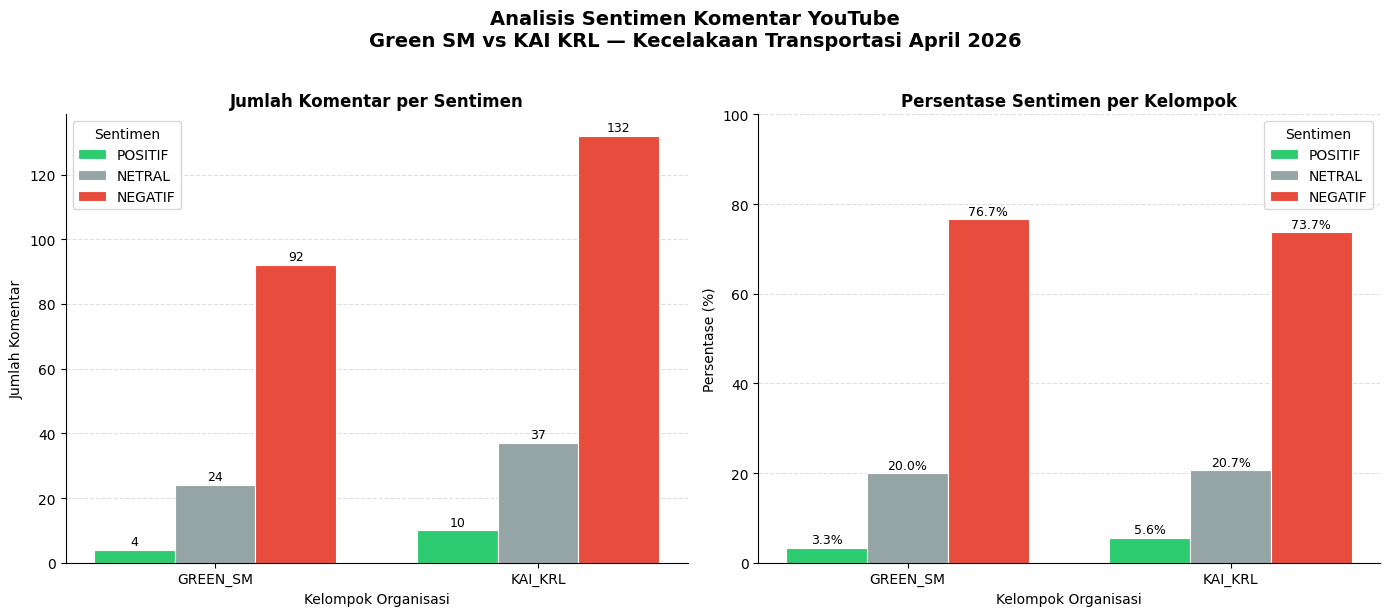


✅ Pipeline selesai! File output:
   📄 hasil_sentimen_semua_komentar.csv
   🖼️  visualisasi_sentimen.png
   🔍 sampel_validasi_manual.csv



/tmp/ipykernel_8152/1041698397.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(


In [ ]:
def main():
    print("\n" + "=" * 60)
    print("  PIPELINE ANALISIS SENTIMEN KOMENTAR YOUTUBE")
    print("  Green SM vs KAI KRL — April 2026")
    print("=" * 60 + "\n")

    if YOUTUBE_API_KEY == "MASUKKAN_API_KEY_ANDA_DI_SINI":
        logger.error("API key belum diisi! Ubah variabel YOUTUBE_API_KEY di bagian KONFIGURASI.")
        sys.exit(1)

    if len(VIDEO_URLS) != 10:
        logger.warning(f"Jumlah video URL = {len(VIDEO_URLS)} (diharapkan 10). Melanjutkan...")

    group_map = VIDEO_GROUP_MAP if VIDEO_GROUP_MAP else build_group_map_auto(VIDEO_URLS)
    logger.info(f"Group map: {group_map}")

    df_raw = fetch_all_comments(
        api_key=YOUTUBE_API_KEY,
        video_urls=VIDEO_URLS,
        group_map=group_map,
        max_per_video=MAX_COMMENTS_PER_VIDEO,
    )

    if df_raw.empty:
        logger.error("Tidak ada komentar yang berhasil diambil. Periksa API key dan URL video.")
        sys.exit(1)

    df_clean = preprocess_comments(df_raw, min_words=MIN_WORD_COUNT)

    classifier = load_sentiment_model(SENTIMENT_MODEL)
    df_result  = classify_comments(df_clean, classifier)

    agg = aggregate_by_group(df_result)

    kolom_output = [
        "video_id", "kelompok", "comment_id", "author",
        "teks_asli", "teks_bersih", "jumlah_kata", "jumlah_like",
        "published_at", "sentimen", "confidence_score",
    ]
    df_result[[k for k in kolom_output if k in df_result.columns]].to_csv(
        OUTPUT_CSV, index=False, encoding="utf-8-sig"
    )
    logger.info(f"Hasil lengkap disimpan: {OUTPUT_CSV}")

    print_summary(df_result, agg)

    visualize_sentiment(agg, VISUALIZATION_FILE)

    export_validation_sample(df_result, VALIDATION_CSV, sample_fraction=0.10)

    print("\n✅ Pipeline selesai! File output:")
    print(f"   📄 {OUTPUT_CSV}")
    print(f"   🖼️  {VISUALIZATION_FILE}")
    print(f"   🔍 {VALIDATION_CSV}\n")



if __name__ == "__main__":
    main()